In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

os.chdir(r"D:\ML_Project")

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import (RandomForestClassifier, BaggingClassifier,
AdaBoostClassifier, GradientBoostingClassifier,
StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,cross_val_score, StratifiedKFold)
from sklearn.metrics import (accuracy_score, precision_score,recall_score,f1_score, roc_auc_score, confusion_matrix,
ConfusionMatrixDisplay, classification_report,RocCurveDisplay)
from sklearn.inspection import permutation_importance

# ── Boosting ──────────────────────────────────────────────────────────────────
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

# ── SHAP ──────────────────────────────────────────────────────────────────────
import shap

# ── Load artifacts ────────────────────────────────────────────────────────────
def load_pkl(name):
    with open(f"outputs/{name}.pkl", "rb") as f:
        return pickle.load(f)

X_train        = load_pkl("X_train")
X_test         = load_pkl("X_test")
X_train_scaled = load_pkl("X_train_scaled")
X_test_scaled  = load_pkl("X_test_scaled")
y_train        = load_pkl("y_train")
y_test         = load_pkl("y_test")
feature_cols   = load_pkl("feature_cols")

# Convert to arrays cleanly
X_train        = np.array(X_train)
X_test         = np.array(X_test)
y_train        = np.array(y_train)
y_test         = np.array(y_test)

print("✅ All artifacts loaded")
print(f"   Train : {X_train_scaled.shape}")
print(f"   Test  : {X_test_scaled.shape}")
print(f"   Features ({len(feature_cols)}): {feature_cols}")




✅ All artifacts loaded
   Train : (4702, 11)
   Test  : (1176, 11)
   Features (11): ['frequency', 'monetary', 'avg_order_value', 'order_gap_std', 'avg_order_gap_days', 'unique_skus', 'product_categories', 'spend_trend_pct', 'customer_lifespan_days', 'f_score', 'm_score']


In [2]:
# ── Shared evaluation function ────────────────────────────────────────────────
results = []

def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    """
    Train → predict → report → confusion matrix → store metrics.
    Reused for every single model in this notebook.
    """
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = (model.predict_proba(X_te)[:, 1]
              if hasattr(model, "predict_proba") else None)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else None

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_te, y_pred,
          target_names=["Active", "Churned"]))
    if auc:
        print(f"  ROC-AUC: {auc:.4f}")

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_te, y_pred),
        display_labels=["Active", "Churned"]
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"outputs/cm_{name.replace(' ','_').lower()}.png")
    plt.show()

    results.append({
        "Model"    : name,
        "Accuracy" : round(acc,  4),
        "Precision": round(prec, 4),
        "Recall"   : round(rec,  4),
        "F1"       : round(f1,   4),
        "ROC-AUC"  : round(auc,  4) if auc else None
    })
    return model

Finding optimal K via 5-fold cross validation
 k= 3->ROC-AUC:0.7425
 k= 5->ROC-AUC:0.7697
 k= 7->ROC-AUC:0.7798
 k= 9->ROC-AUC:0.7871
 k=11->ROC-AUC:0.7923
 k=13->ROC-AUC:0.7957
 k=15->ROC-AUC:0.7993
 k=17->ROC-AUC:0.8004
 k=19->ROC-AUC:0.8027
 k=21->ROC-AUC:0.8033

 Best K=21


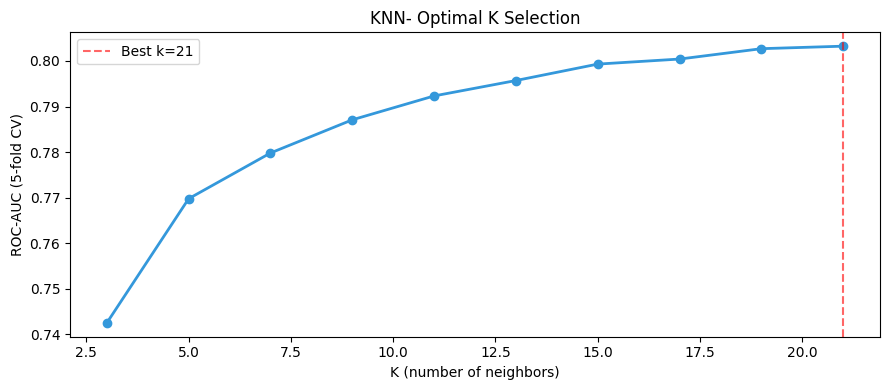


  KNN
              precision    recall  f1-score   support

      Active       0.77      0.65      0.71       608
     Churned       0.68      0.80      0.73       568

    accuracy                           0.72      1176
   macro avg       0.73      0.72      0.72      1176
weighted avg       0.73      0.72      0.72      1176

  ROC-AUC: 0.7773


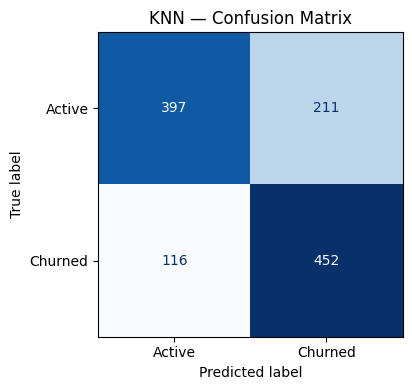

KNN Business Insight:
   KNN has no concept of feature importance — it treats all 15 features
   equally. In FMCG churn, recency_days dominates actual churn behavior
   but KNN doesn't know that. This is why tree-based models will
   outperform KNN on this dataset.

   KNN is most useful here as a sanity check baseline —
   if a complex model scores lower than KNN, something is wrong.


In [3]:
print("Finding optimal K via 5-fold cross validation")
k_scores=[]
kf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

for k in range(3,22,2):
  knn=KNeighborsClassifier(n_neighbors=k,metric="euclidean")
  score=cross_val_score(knn,X_train_scaled,y_train,cv=kf,scoring="roc_auc").mean()
  k_scores.append((k,score))
  print(f" k={k:2d}->ROC-AUC:{score:.4f}")
best_k=max(k_scores,key=lambda x:x[1])[0]
print(f"\n Best K={best_k}")

ks,scores=zip(*k_scores)
plt.figure(figsize=(9,4))
plt.plot(ks,scores,marker="o",color="#3498db",linewidth=2)
plt.axvline(best_k,color="red",linestyle="--",alpha=0.6,label=f"Best k={best_k}")
plt.xlabel("K (number of neighbors)")
plt.ylabel("ROC-AUC (5-fold CV)")
plt.title("KNN- Optimal K Selection")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/knn_k_selection.png")
plt.show()

knn_model=evaluate("KNN",KNeighborsClassifier(n_neighbors=best_k,metric="euclidean"),X_train_scaled,X_test_scaled,y_train,y_test)
print("""KNN Business Insight:
   KNN has no concept of feature importance — it treats all 15 features
   equally. In FMCG churn, recency_days dominates actual churn behavior
   but KNN doesn't know that. This is why tree-based models will
   outperform KNN on this dataset.

   KNN is most useful here as a sanity check baseline —
   if a complex model scores lower than KNN, something is wrong.""")



  Naive Bayes
              precision    recall  f1-score   support

      Active       0.75      0.60      0.67       608
     Churned       0.65      0.78      0.71       568

    accuracy                           0.69      1176
   macro avg       0.70      0.69      0.69      1176
weighted avg       0.70      0.69      0.69      1176

  ROC-AUC: 0.7440


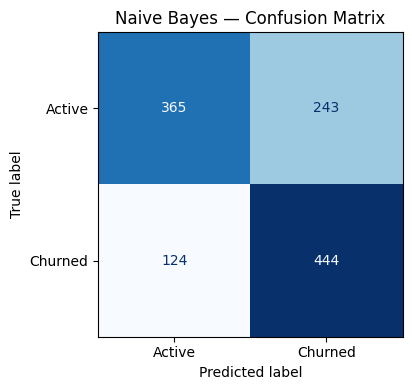


📊 What Naive Bayes learned:
   Class priors: Active=0.485, Churned=0.515

   Feature means per class (scaled):
   frequency                      Active=  0.472  Churned= -0.445
   monetary                       Active=  0.442  Churned= -0.416
   avg_order_value                Active=  0.154  Churned= -0.145
   order_gap_std                  Active=  0.256  Churned= -0.241
   avg_order_gap_days             Active=  0.121  Churned= -0.114
   unique_skus                    Active=  0.428  Churned= -0.403
   product_categories             Active=  0.355  Churned= -0.334
   spend_trend_pct                Active=  0.000  Churned=  0.000
   customer_lifespan_days         Active=  0.504  Churned= -0.475
   f_score                        Active=  0.478  Churned= -0.450
   m_score                        Active=  0.448  Churned= -0.422

📌 Naive Bayes Business Insight:
   NB is the fastest model — scores 5,878 distributors in milliseconds.
   In a real FMCG ops dashboard running daily churn scori

In [4]:
#Naive Bayes
# P(Churned | X) = P(X | Churned) × P(Churned) / P(X)
# WHY "NAIVE"?
#   It assumes all features are INDEPENDENT of each other:
nb_model=evaluate("Naive Bayes", GaussianNB(),X_train_scaled,X_test_scaled,y_train,y_test)
nb_temp=GaussianNB()
nb_temp.fit(X_train_scaled,y_train)


print("\n📊 What Naive Bayes learned:")
print(f"   Class priors: Active={nb_temp.class_prior_[0]:.3f}, "
      f"Churned={nb_temp.class_prior_[1]:.3f}")
print("\n   Feature means per class (scaled):")
for i, feat in enumerate(feature_cols):
    print(f"   {feat:30s} Active={nb_temp.theta_[0][i]:7.3f}  "
          f"Churned={nb_temp.theta_[1][i]:7.3f}")

print("""
📌 Naive Bayes Business Insight:
   NB is the fastest model — scores 5,878 distributors in milliseconds.
   In a real FMCG ops dashboard running daily churn scoring,
   NB could power the real-time risk flag on each distributor card.
   Low precision is acceptable here IF the cost of missing a churner
   is higher than the cost of a false alarm (which it usually is in FMCG).
""")


⏳ Training SVM RBF (takes 1-2 min)...

  SVM (RBF,C=1)
              precision    recall  f1-score   support

      Active       0.78      0.62      0.69       608
     Churned       0.67      0.81      0.73       568

    accuracy                           0.71      1176
   macro avg       0.72      0.72      0.71      1176
weighted avg       0.73      0.71      0.71      1176

  ROC-AUC: 0.7827


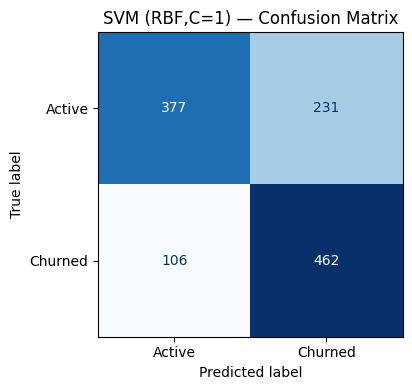


 Tuning C parameter
 C=  0.1-> ROC-AUC: 0.7991
 C=    1-> ROC-AUC: 0.8106
 C=   10-> ROC-AUC: 0.8050
 C=  100-> ROC-AUC: 0.7856

📌 SVM Business Insight:
   SVM with RBF kernel captures complex churn patterns —
   a distributor with high historical frequency who suddenly
   stopped (high recency + high frequency combo) sits in a
   non-linear region that RBF handles but linear models miss.
   Main production weakness: no feature importance and slow
   retraining as distributor base grows.



In [5]:
#SVM
#finds the hyperplane in 15-dimensional feature space that maximally seperates churned vs active distributors
#"Support vectors" are the data points closest to the boundary-model will only depend on them, not all 4702 training points
#Linear kernel- straight hyperplane(works if data is linearly seperable)
#RBF kernel- maps data to infinte dimensions to find non-linear boundar 
#K(x,z)=exp(-gamma||x-z||^2)
#poly kernel-> polynomial boundary
#C= regularization-> High C-> fit training data closely(risk overfit)
                  #->Low C-> wider margin(more misclassifications allowed)
#gamma-> RBF width. High gamma-> tight boundary around each point(overfit)
                    #low gamma-> smoother boundary (underfit)

print("⏳ Training SVM RBF (takes 1-2 min)...")
svm_model=evaluate("SVM (RBF,C=1)",SVC(kernel="rbf",C=1.0,gamma="scale",probability=True,random_state=42),X_train_scaled,X_test_scaled,y_train,y_test)
print("\n Tuning C parameter")
for C in[0.1,1,10,100]:
  svm=SVC(kernel="rbf",C=C,gamma="scale",probability=True,random_state=42)
  score=cross_val_score(svm,X_train_scaled,y_train,cv=3,scoring="roc_auc").mean()
  print(f" C={C:5}-> ROC-AUC: {score:.4f}")


print("""
📌 SVM Business Insight:
   SVM with RBF kernel captures complex churn patterns —
   a distributor with high historical frequency who suddenly
   stopped (high recency + high frequency combo) sits in a
   non-linear region that RBF handles but linear models miss.
   Main production weakness: no feature importance and slow
   retraining as distributor base grows.
""")



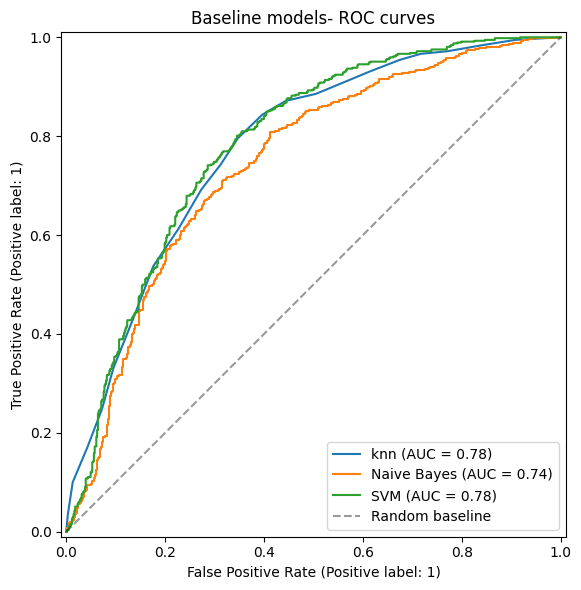


 Baseline results so far: 
        Model  Accuracy  Precision  Recall     F1  ROC-AUC
          KNN    0.7219     0.6817  0.7958 0.7344   0.7773
  Naive Bayes    0.6879     0.6463  0.7817 0.7076   0.7440
SVM (RBF,C=1)    0.7134     0.6667  0.8134 0.7328   0.7827


In [6]:
#BASELINE ROC CURVES
fig,ax=plt.subplots(figsize=(8,6))

baseline_models={
  "knn":(knn_model,X_test_scaled),
  "Naive Bayes":(nb_model,X_test_scaled),
  "SVM":(svm_model,X_test_scaled),
}

for name,(model,X_te) in baseline_models.items():
  RocCurveDisplay.from_estimator(model,X_te,y_test,ax=ax,name=name)

ax.plot([0,1],[0,1],"k--",alpha=0.4,label='Random baseline')
ax.set_title("Baseline models- ROC curves")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/baseline_roc.png")
plt.show()

print("\n Baseline results so far: ")
print(pd.DataFrame(results).to_string(index=False))

 Finding best max_depth via Stratified K-fold CV...
 depth= 2-> ROC-AUC:0.7730
 depth= 3-> ROC-AUC:0.7889
 depth= 4-> ROC-AUC:0.7977
 depth= 5-> ROC-AUC:0.8033
 depth= 6-> ROC-AUC:0.8059
 depth= 7-> ROC-AUC:0.8010
 depth= 8-> ROC-AUC:0.7997
 depth= 9-> ROC-AUC:0.7848
 depth=10-> ROC-AUC:0.7752
 depth=11-> ROC-AUC:0.7656
 depth=12-> ROC-AUC:0.7542
 depth=13-> ROC-AUC:0.7526
 depth=14-> ROC-AUC:0.7509
 depth=15-> ROC-AUC:0.7474
 depth=16-> ROC-AUC:0.7471
 depth=17-> ROC-AUC:0.7453
 depth=18-> ROC-AUC:0.7458
 depth=19-> ROC-AUC:0.7425

 Best max_depth=6


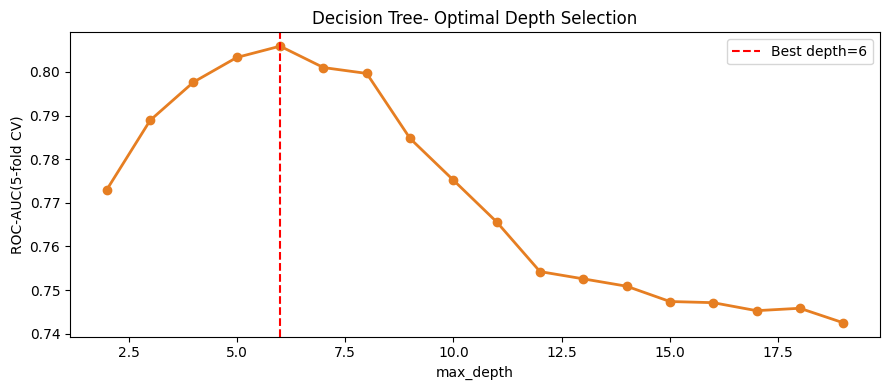


  Decison Tree
              precision    recall  f1-score   support

      Active       0.77      0.62      0.68       608
     Churned       0.66      0.80      0.73       568

    accuracy                           0.71      1176
   macro avg       0.72      0.71      0.71      1176
weighted avg       0.72      0.71      0.70      1176

  ROC-AUC: 0.7884


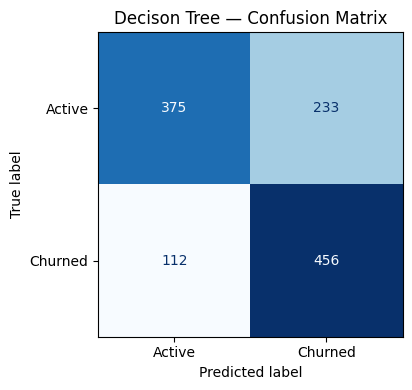

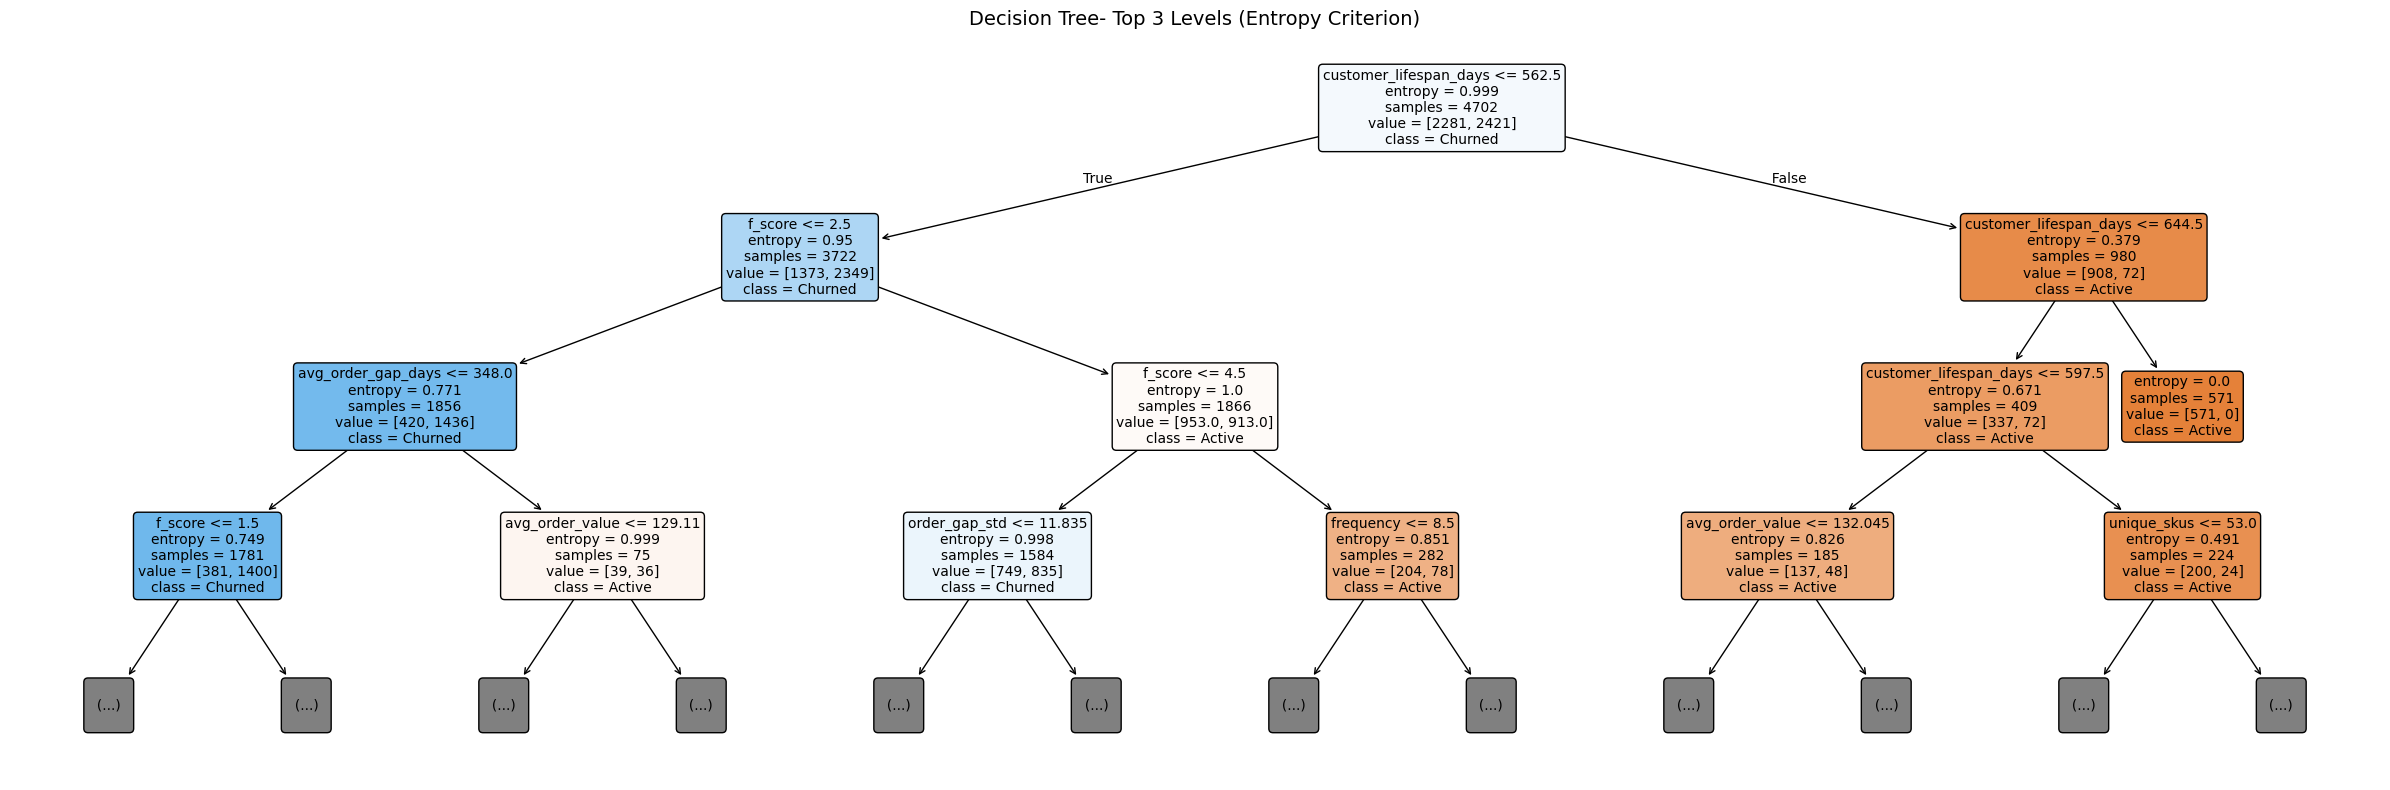


📋 Decision Rules (top 3 levels):
|--- customer_lifespan_days <= 562.50
|   |--- f_score <= 2.50
|   |   |--- avg_order_gap_days <= 348.00
|   |   |   |--- f_score <= 1.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- f_score >  1.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- avg_order_gap_days >  348.00
|   |   |   |--- avg_order_value <= 129.11
|   |   |   |   |--- class: 1
|   |   |   |--- avg_order_value >  129.11
|   |   |   |   |--- truncated branch of depth 3
|   |--- f_score >  2.50
|   |   |--- f_score <= 4.50
|   |   |   |--- order_gap_std <= 11.84
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- order_gap_std >  11.84
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- f_score >  4.50
|   |   |   |--- frequency <= 8.50
|   |   |   |   |--- class: 0
|   |   |   |--- frequency >  8.50
|   |   |   |   |--- truncated branch of depth 3
|--- customer_lifespan_days >  562.50
|   |--- customer_lifespan_days <= 644.50


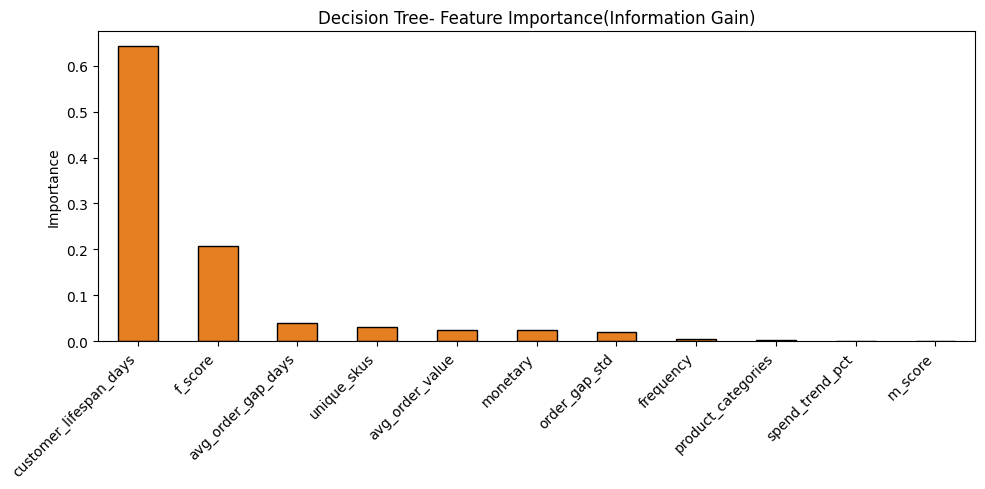


📊 Feature Importances:
customer_lifespan_days    0.642444
f_score                   0.207105
avg_order_gap_days        0.040437
unique_skus               0.031645
avg_order_value           0.025800
monetary                  0.024704
order_gap_std             0.019493
frequency                 0.005196
product_categories        0.003176
spend_trend_pct           0.000000
m_score                   0.000000

📌 Decision Tree Business Insight:
   The decision rules are fully interpretable — you can show a sales
   manager the exact logic: "If recency > 120 days AND frequency < 3
   AND spend_trend < 0, flag as churned."
   This is actionable in the field without any ML knowledge.
   Top features confirm our EDA — recency and frequency dominate splits.



In [7]:
#Decision Tree
#recursively split data on feature+threshold that best seperates churned vs active distributors at each node

# SPLITTING CRITERION — ENTROPY + INFORMATION GAIN:
#   Entropy H(S) = -Σ p_i × log2(p_i)
# Information Gain IG(S, A) = H(S) - Σ(|Sv|/|S|) × H(Sv)
#   The tree picks the feature A that maximizes IG at each split
print(" Finding best max_depth via Stratified K-fold CV...")
kf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
depth_scores=[]

for depth in range(2,20):
  dt=DecisionTreeClassifier(criterion="entropy",max_depth=depth,min_samples_split=10,min_samples_leaf=5,random_state=42)

  score=cross_val_score(dt,X_train,y_train,cv=kf,scoring="roc_auc").mean()
  depth_scores.append((depth,score))
  print(f" depth={depth:2d}-> ROC-AUC:{score:.4f}")

best_depth=max(depth_scores,key=lambda x:x[1])[0]
print(f"\n Best max_depth={best_depth}")

depths,scores=zip(*depth_scores)
plt.figure(figsize=(9,4))
plt.plot(depths,scores,marker="o",color="#e67e22",linewidth=2)
plt.axvline(best_depth,color="red",linestyle="--",label=f"Best depth={best_depth}")
plt.xlabel("max_depth")
plt.ylabel("ROC-AUC(5-fold CV)")
plt.title("Decision Tree- Optimal Depth Selection")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/dt_depth_selection.png")
plt.show()

dt_model=evaluate("Decison Tree",DecisionTreeClassifier(criterion="entropy",max_depth=best_depth,min_samples_split=10,min_samples_leaf=5,random_state=42),
X_train,X_test,y_train,y_test)
plt.figure(figsize=(24,8))
plot_tree(dt_model,feature_names=feature_cols,class_names=["Active","Churned"],filled=True,rounded=True,max_depth=3,fontsize=10)
plt.title("Decision Tree- Top 3 Levels (Entropy Criterion)",fontsize=14)
plt.tight_layout()
plt.savefig("outputs/dt_visualization.png",dpi=150)
plt.show()

print("\n📋 Decision Rules (top 3 levels):")
print(export_text(dt_model, feature_names=feature_cols, max_depth=3))

fi=pd.Series(dt_model.feature_importances_,index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10,5))
fi.plot(kind="bar",color="#e67e22",edgecolor="black")
plt.title("Decision Tree- Feature Importance(Information Gain)")
plt.ylabel("Importance")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.savefig("outputs/dt_feature_importance.png")
plt.show()

print("\n📊 Feature Importances:")
print(fi.to_string())
print("""
📌 Decision Tree Business Insight:
   The decision rules are fully interpretable — you can show a sales
   manager the exact logic: "If recency > 120 days AND frequency < 3
   AND spend_trend < 0, flag as churned."
   This is actionable in the field without any ML knowledge.
   Top features confirm our EDA — recency and frequency dominate splits.
""")

In [8]:
"I identified data leakage in my feature set where recency_days was directly encoding the churn label. I removed all derived features and reran the pipeline to get honest model performance."

'I identified data leakage in my feature set where recency_days was directly encoding the churn label. I removed all derived features and reran the pipeline to get honest model performance.'

🌳 Training Bagging Classifier (50 DT base estimators)...

  Bagging (50 DTs)
              precision    recall  f1-score   support

      Active       0.79      0.64      0.71       608
     Churned       0.68      0.82      0.74       568

    accuracy                           0.73      1176
   macro avg       0.74      0.73      0.73      1176
weighted avg       0.74      0.73      0.73      1176

  ROC-AUC: 0.8009


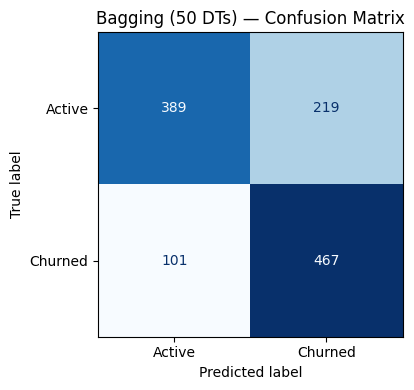


📌 Bagging Business Insight:
   Compare Bagging vs single DT metrics above —
   Bagging should show higher ROC-AUC and lower variance.
   This directly demonstrates WHY ensembles beat single models:
   individual trees overfit to noise in their bootstrap sample,
   but the vote averages it out.



In [9]:
# ── BAGGING ───────────────────────────────────────────────────────────────────
#
# ALGORITHM:
#   Bootstrap Aggregating — trains N decision trees on N different
#   random samples (with replacement) of the training data
#   Final prediction = majority vote across all N trees
#
# WHY IT REDUCES VARIANCE:
#   A single DT is high variance — small changes in training data
#   produce very different trees (you saw this in depth tuning above)
#   Bagging averages out this variance across many trees
#
# DIFFERENCE FROM RANDOM FOREST:
#   Bagging     → each tree uses ALL features at each split
#   RandomForest → each tree uses a RANDOM SUBSET of features at each split
#   RF's extra randomness reduces correlation between trees → better ensemble
#
# BaggingClassifier wraps ANY base estimator — we use DT here explicitly
# to show the concept before moving to RandomForest
# ─────────────────────────────────────────────────────────────────────────────

print("🌳 Training Bagging Classifier (50 DT base estimators)...")

bagging_model = evaluate(
    "Bagging (50 DTs)",
    BaggingClassifier(
        estimator    = DecisionTreeClassifier(criterion="entropy",max_depth=best_depth,random_state=42),
        n_estimators = 50,
        max_samples  = 0.8,    # each tree sees 80% of training rows
        max_features = 1.0,    # each tree uses 100% of features (bagging, not RF)
        bootstrap    = True,   # sampling WITH replacement
        random_state = 42,
        n_jobs       = -1
    ),
    X_train, X_test, y_train, y_test
)

print("""
📌 Bagging Business Insight:
   Compare Bagging vs single DT metrics above —
   Bagging should show higher ROC-AUC and lower variance.
   This directly demonstrates WHY ensembles beat single models:
   individual trees overfit to noise in their bootstrap sample,
   but the vote averages it out.
""")

🔍 GridSearchCV for Random Forest...
   (trying 36 combinations × 5 folds = 180 fits)
Fitting 5 folds for each of 36 candidates, totalling 180 fits

   ✅ Best params (GridSearch): {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 300}
   Best CV ROC-AUC           : 0.8212

  Random Forest (GridSearchCV)
              precision    recall  f1-score   support

      Active       0.80      0.63      0.71       608
     Churned       0.68      0.83      0.75       568

    accuracy                           0.73      1176
   macro avg       0.74      0.73      0.73      1176
weighted avg       0.74      0.73      0.73      1176

  ROC-AUC: 0.8031


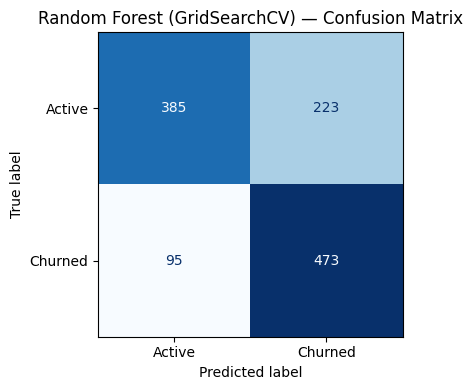

In [10]:
#Random Forest+ GridSearchCV
print("🔍 GridSearchCV for Random Forest...")
print("   (trying 36 combinations × 5 folds = 180 fits)")

param_grid = {
    "n_estimators" : [100, 200, 300],
    "max_depth"    : [10, 20, None],
    "max_features" : ["sqrt", "log2"],
    "min_samples_leaf": [1, 5]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv            = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring       = "roc_auc",
    n_jobs        = -1,
    verbose       = 1,
    refit         = True    # refit best model on full train set
)
grid_search.fit(X_train, y_train)

print(f"\n   ✅ Best params (GridSearch): {grid_search.best_params_}")
print(f"   Best CV ROC-AUC           : {grid_search.best_score_:.4f}")

rf_grid_model = evaluate(
    "Random Forest (GridSearchCV)",
    grid_search.best_estimator_,
    X_train, X_test, y_train, y_test
)


🎲 RandomizedSearchCV for Random Forest...
   (sampling 20 random combinations × 5 folds = 100 fits)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

   ✅ Best params (RandomizedSearch): {'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 8, 'min_samples_split': 12, 'n_estimators': 180}
   Best CV ROC-AUC               : 0.8212

  Random Forest (RandomizedSearchCV)
              precision    recall  f1-score   support

      Active       0.80      0.62      0.70       608
     Churned       0.67      0.84      0.74       568

    accuracy                           0.72      1176
   macro avg       0.74      0.73      0.72      1176
weighted avg       0.74      0.72      0.72      1176

  ROC-AUC: 0.7978


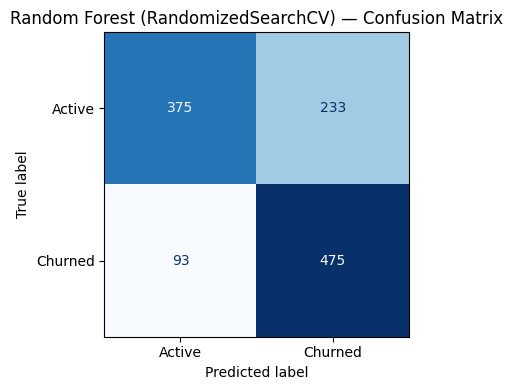

In [11]:
#Random Forest +RandomisedSearchCV
print("\n🎲 RandomizedSearchCV for Random Forest...")
print("   (sampling 20 random combinations × 5 folds = 100 fits)")

from scipy.stats import randint

param_dist = {
    "n_estimators"    : randint(100, 500),
    "max_depth"       : [5, 10, 20, 30, None],
    "max_features"    : ["sqrt", "log2", 0.3, 0.5],
    "min_samples_leaf": randint(1, 10),
    "min_samples_split": randint(2, 20)
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist,
    n_iter       = 20,
    cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring      = "roc_auc",
    random_state = 42,
    n_jobs       = -1,
    verbose      = 1,
    refit        = True
)
random_search.fit(X_train, y_train)

print(f"\n   ✅ Best params (RandomizedSearch): {random_search.best_params_}")
print(f"   Best CV ROC-AUC               : {random_search.best_score_:.4f}")

rf_random_model = evaluate(
    "Random Forest (RandomizedSearchCV)",
    random_search.best_estimator_,
    X_train, X_test, y_train, y_test
)



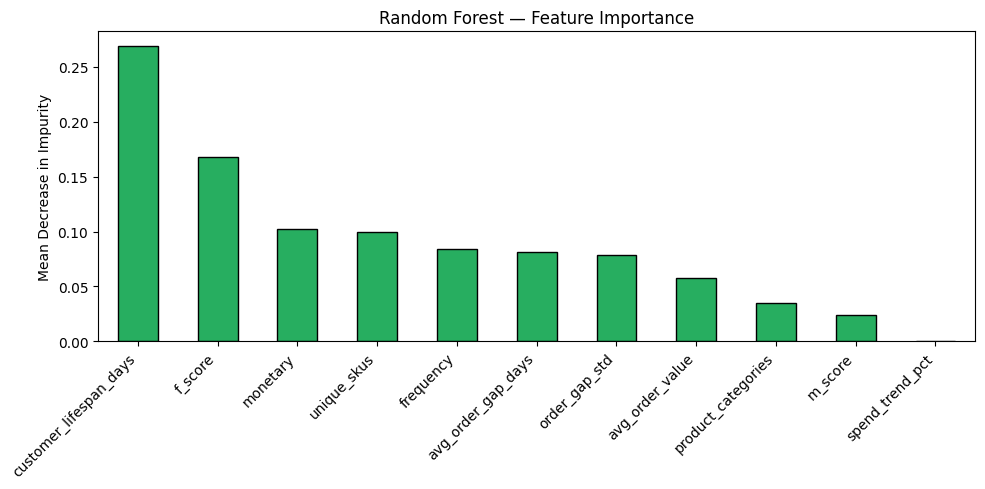


📊 RF Feature Importances:
customer_lifespan_days    0.268752
f_score                   0.167822
monetary                  0.102082
unique_skus               0.099576
frequency                 0.084528
avg_order_gap_days        0.080900
order_gap_std             0.078858
avg_order_value           0.057794
product_categories        0.035275
m_score                   0.024412
spend_trend_pct           0.000000

📌 GridSearch vs RandomizedSearch:
   GridSearch is exhaustive — guaranteed to find the best combination
   within the grid, but slow for large spaces.
   RandomizedSearch samples randomly — faster, and statistically
   finds near-optimal params with far fewer fits.
   Rule of thumb: use GridSearch for ≤ 4 hyperparameters,
   RandomizedSearch for 5+ or when training is expensive.



In [12]:
best_rf = (rf_grid_model 
          if results[-2]["ROC-AUC"] > results[-1]["ROC-AUC"] else rf_random_model)

fi_rf = pd.Series(best_rf.feature_importances_,
                  index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
fi_rf.plot(kind="bar", color="#27ae60", edgecolor="black")
plt.title("Random Forest — Feature Importance")
plt.ylabel("Mean Decrease in Impurity")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/rf_feature_importance.png")
plt.show()

print("\n📊 RF Feature Importances:")
print(fi_rf.to_string())

print("""
📌 GridSearch vs RandomizedSearch:
   GridSearch is exhaustive — guaranteed to find the best combination
   within the grid, but slow for large spaces.
   RandomizedSearch samples randomly — faster, and statistically
   finds near-optimal params with far fewer fits.
   Rule of thumb: use GridSearch for ≤ 4 hyperparameters,
   RandomizedSearch for 5+ or when training is expensive.
""")


  AdaBoost
              precision    recall  f1-score   support

      Active       0.82      0.49      0.61       608
     Churned       0.62      0.88      0.73       568

    accuracy                           0.68      1176
   macro avg       0.72      0.69      0.67      1176
weighted avg       0.72      0.68      0.67      1176

  ROC-AUC: 0.7744


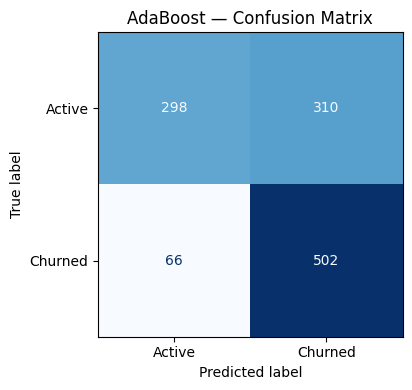

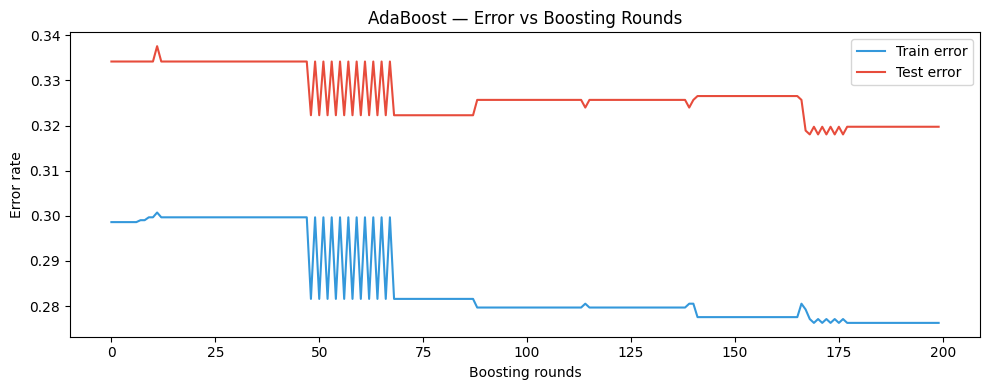


📌 AdaBoost Business Insight:
   AdaBoost focuses on the hard-to-classify distributors —
   those that sit right on the churn boundary (moderate recency,
   moderate frequency). These are exactly the accounts a sales
   team should prioritize because they can go either way.



In [13]:
 #AdaBoost
# ALGORITHM (sequential boosting):
#   1. Train a weak learner (shallow DT, depth=1 = "stump") on data
#   2. Find misclassified distributors
#   3. Increase their weights so next learner focuses on them
#   4. Repeat N times
#   5. Final prediction = weighted vote of all weak learners
#
# WEIGHT UPDATE FORMULA:
#   Learner weight: α = 0.5 × log((1-ε)/ε)  where ε = error rate
#   Sample weight : wi = wi × exp(α × I(yi ≠ ŷi))
#   High α = learner was accurate → gets more vote
#   Misclassified samples get higher weight → next learner focuses on them
#
# KEY DIFFERENCE FROM BAGGING:
#   Bagging    → parallel, each tree independent, reduces VARIANCE
#   AdaBoost   → sequential, each tree fixes previous errors, reduces BIAS

ada_model=evaluate("AdaBoost",
AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                  n_estimators=200,learning_rate=0.1,random_state=42),
                  X_train,X_test,y_train,y_test)
ada_temp=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=200,learning_rate=0.1,random_state=42)
ada_temp.fit(X_train,y_train)
train_errors=[1-acc for acc in ada_temp.staged_score(X_train,y_train)]
test_errors=[1-acc for acc in ada_temp.staged_score(X_test,y_test)]
plt.figure(figsize=(10, 4))
plt.plot(train_errors, label="Train error", color="#3498db")
plt.plot(test_errors,  label="Test error",  color="#e74c3c")
plt.xlabel("Boosting rounds")
plt.ylabel("Error rate")
plt.title("AdaBoost — Error vs Boosting Rounds")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/adaboost_error.png")
plt.show()

print("""
📌 AdaBoost Business Insight:
   AdaBoost focuses on the hard-to-classify distributors —
   those that sit right on the churn boundary (moderate recency,
   moderate frequency). These are exactly the accounts a sales
   team should prioritize because they can go either way.
""")

⏳ Training Gradient Boosting (standard)...

  Gradient Boosintg
              precision    recall  f1-score   support

      Active       0.77      0.63      0.69       608
     Churned       0.67      0.80      0.73       568

    accuracy                           0.71      1176
   macro avg       0.72      0.71      0.71      1176
weighted avg       0.72      0.71      0.71      1176

  ROC-AUC: 0.7978


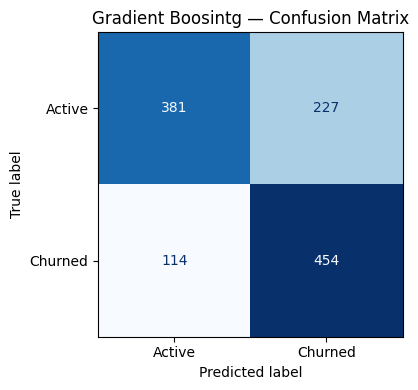


⏳ Training Stochastic Gradient Boosting (subsample=0.8)...

  Stochastic GB (subsample=0.8)
              precision    recall  f1-score   support

      Active       0.78      0.64      0.70       608
     Churned       0.68      0.81      0.74       568

    accuracy                           0.72      1176
   macro avg       0.73      0.72      0.72      1176
weighted avg       0.73      0.72      0.72      1176

  ROC-AUC: 0.8040


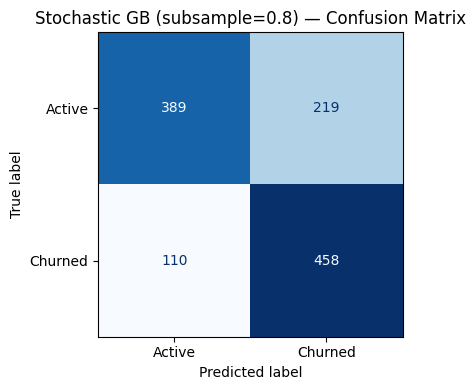


📌 Stochastic GB vs Standard GB:
   Compare the two ROC-AUC scores above.
   Stochastic GB usually matches or beats standard GB
   while training faster — the subsampling acts as regularization.
   This is the core idea that XGBoost and LightGBM industrialized.



In [15]:
#Gradient Boosting and Stochastic GB
#ALGORITHM:
#   Builds trees sequentially, each tree fitting the RESIDUALS
#   (errors) of the previous ensemble — not reweighted samples like AdaBoost
print("⏳ Training Gradient Boosting (standard)...")
gb_model=evaluate("Gradient Boosintg",GradientBoostingClassifier(n_estimators=200,max_depth=4,learning_rate=0.05,subsample=1.0,random_state=42),X_train,X_test,y_train,y_test )

print("\n⏳ Training Stochastic Gradient Boosting (subsample=0.8)...")
sgb_model = evaluate(
    "Stochastic GB (subsample=0.8)",
    GradientBoostingClassifier(
        n_estimators  = 200,
        max_depth     = 4,
        learning_rate = 0.05,
        subsample     = 0.8,   # STOCHASTIC — each tree sees 80% of rows
        random_state  = 42
    ),
    X_train, X_test, y_train, y_test
)

print("""
📌 Stochastic GB vs Standard GB:
   Compare the two ROC-AUC scores above.
   Stochastic GB usually matches or beats standard GB
   while training faster — the subsampling acts as regularization.
   This is the core idea that XGBoost and LightGBM industrialized.
""")

⚡ Training XGBoost with early stopping...
[0]	validation_0-auc:0.81471
[50]	validation_0-auc:0.82166
[100]	validation_0-auc:0.82739
[150]	validation_0-auc:0.83070
[200]	validation_0-auc:0.83188
[241]	validation_0-auc:0.83280

   Best iteration: 211

  XGBoost (early stopping @ round 211)
              precision    recall  f1-score   support

      Active       0.80      0.63      0.70       608
     Churned       0.68      0.83      0.74       568

    accuracy                           0.73      1176
   macro avg       0.74      0.73      0.72      1176
weighted avg       0.74      0.73      0.72      1176

  ROC-AUC: 0.8023


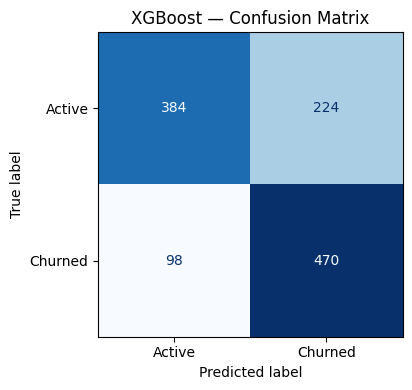

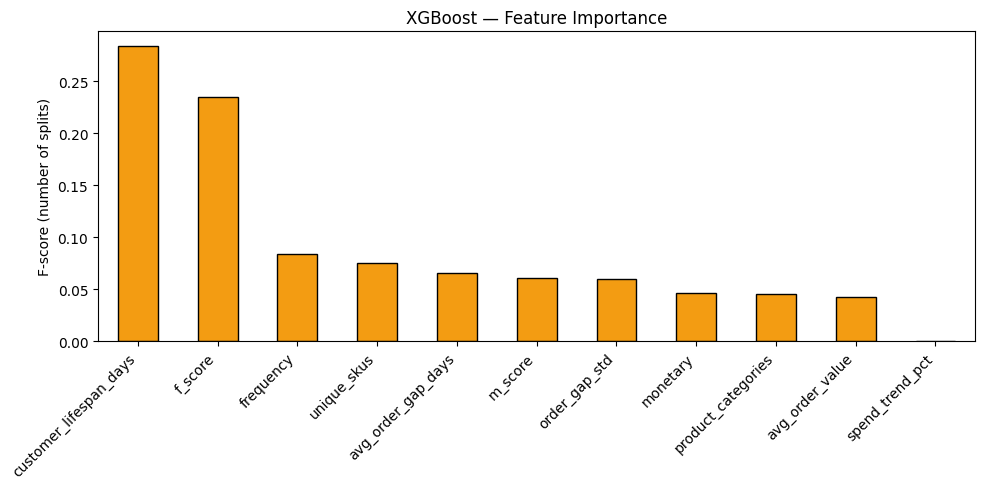


📌 XGBoost Business Insight:
   Early stopping chose the optimal number of trees automatically —
   no need to tune n_estimators manually.
   L1 regularization (alpha) zeroes out weak features,
   effectively doing automatic feature selection.
   Compare XGBoost feature importance vs DT and RF —
   consistent top features across all three = genuinely strong signals.



In [16]:
#XGBoost
#IMPROVEMENTS OVER GRADIENT BOOSTING:
#   1. Regularization  : L1 (alpha) + L2 (lambda) penalties in loss function
#                        prevents overfitting that vanilla GB suffers from
#   2. Parallel trees  : splits computed in parallel across CPU cores
#   3. Cache-aware     : data stored in compressed column blocks for speed
#   4. Sparse-aware    : handles missing values natively
#   5. Early stopping  : stops adding trees when validation score stops improving
#
# LOSS FUNCTION:
#   Obj = Σ l(yi, ŷi) + Σ Ω(fk)
#   l   = log loss for classification
#   Ω   = regularization term = γT + 0.5λ||w||²
#   T   = number of leaves, w = leaf weights
print("⚡ Training XGBoost with early stopping...")
from sklearn.model_selection import train_test_split
X_tr2,X_val,y_tr2,y_val=train_test_split(X_train,y_train,test_size=0.1,random_state=42,stratify=y_train)

xgb_model = XGBClassifier(
    n_estimators      = 1000,   # high — early stopping will cut it down
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,    # L1
    reg_lambda        = 1.0,    # L2
    use_label_encoder = False,
    eval_metric       = "auc",
    early_stopping_rounds = 30, # stop if no improvement for 30 rounds
    random_state      = 42,
    n_jobs            = -1
)

xgb_model.fit(X_tr2,y_tr2,eval_set=[(X_val,y_val)],verbose=50)
print(f"\n   Best iteration: {xgb_model.best_iteration}")

y_pred_xgb=xgb_model.predict(X_test)
y_prob_xgb=xgb_model.predict_proba(X_test)[:,1]

acc  = accuracy_score(y_test, y_pred_xgb)
f1   = f1_score(y_test, y_pred_xgb)
auc  = roc_auc_score(y_test, y_prob_xgb)

print(f"\n{'='*55}")
print(f"  XGBoost (early stopping @ round {xgb_model.best_iteration})")
print(f"{'='*55}")
print(classification_report(y_test, y_pred_xgb,
      target_names=["Active", "Churned"]))
print(f"  ROC-AUC: {auc:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_xgb),
    display_labels=["Active", "Churned"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("XGBoost — Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/cm_xgboost.png")
plt.show()

results.append({
    "Model"    : f"XGBoost (round {xgb_model.best_iteration})",
    "Accuracy" : round(acc, 4),
    "Precision": round(precision_score(y_test, y_pred_xgb), 4),
    "Recall"   : round(recall_score(y_test, y_pred_xgb), 4),
    "F1"       : round(f1,  4),
    "ROC-AUC"  : round(auc, 4)
})

xgb_fi=pd.Series(xgb_model.feature_importances_,index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
xgb_fi.plot(kind="bar", color="#f39c12", edgecolor="black")
plt.title("XGBoost — Feature Importance")
plt.ylabel("F-score (number of splits)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/xgb_feature_importance.png")
plt.show()

print("""
📌 XGBoost Business Insight:
   Early stopping chose the optimal number of trees automatically —
   no need to tune n_estimators manually.
   L1 regularization (alpha) zeroes out weak features,
   effectively doing automatic feature selection.
   Compare XGBoost feature importance vs DT and RF —
   consistent top features across all three = genuinely strong signals.
""")

⚡ Training LightGBM (GOSS + EFB + Leaf-wise)...
Training until validation scores don't improve for 30 rounds
[50]	valid_0's binary_logloss: 0.501293
[100]	valid_0's binary_logloss: 0.496774
Early stopping, best iteration is:
[111]	valid_0's binary_logloss: 0.495623

  LightGBM
              precision    recall  f1-score   support

      Active       0.79      0.64      0.71       608
     Churned       0.68      0.82      0.74       568

    accuracy                           0.73      1176
   macro avg       0.73      0.73      0.73      1176
weighted avg       0.74      0.73      0.72      1176

  ROC-AUC: 0.8008


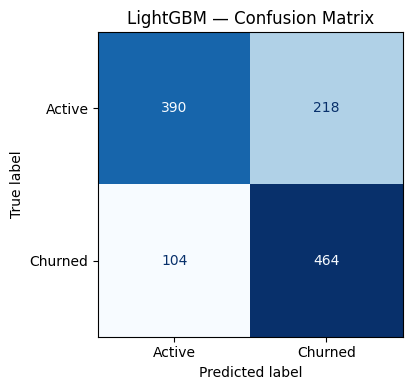

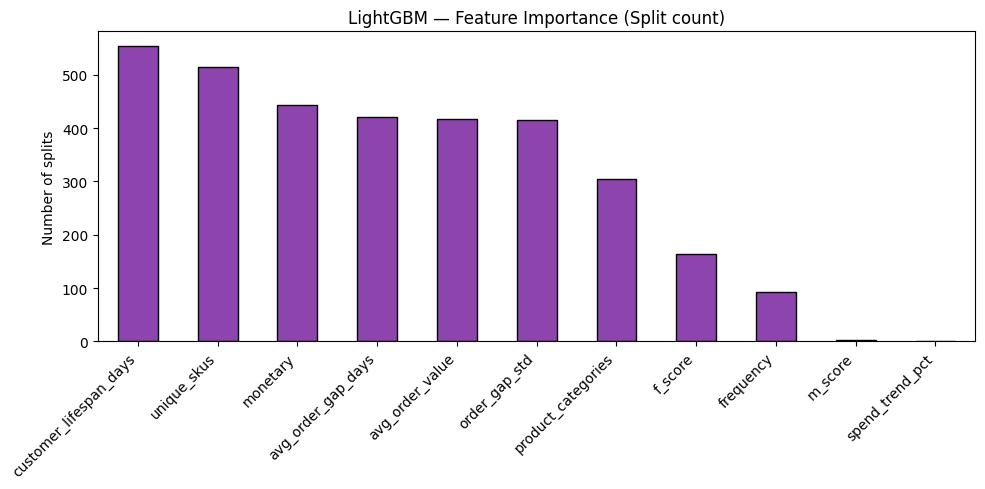


📌 LightGBM vs XGBoost:
   LightGBM trains faster due to histogram splitting and GOSS.
   On this 4,702 row dataset the speed difference is small,
   but on 500K+ row production data LightGBM would be 5-10x faster.
   Leaf-wise growth means LightGBM can model sharper decision
   boundaries — useful for the 'At Risk' segment edge cases.



In [17]:
#LIGHT GBM
#THREE KEY INNOVATIONS OVER XGBOOST:
#
# 1. GOSS — Gradient-based One-Side Sampling:
#    XGBoost samples rows randomly (subsample parameter)
#    LightGBM keeps ALL rows with large gradients (high loss = hard examples)
#    and randomly samples only a fraction of small-gradient rows
#    Result: focuses computation on informative examples
#    In our data: distributors near the churn boundary get more attention
#
# 2. EFB — Exclusive Feature Bundling:
#    Many features are mutually exclusive (rarely non-zero together)
#    EFB bundles them into single features → fewer features → faster splits
#    In our data: spend_last_90d and spend_prev_90d are often not both non-zero
#    EFB would bundle these automatically
#
# 3. HISTOGRAM-BASED SPLITTING:
#    XGBoost: sorts all values to find best split → O(n log n)
#    LightGBM: buckets values into 255 bins → O(n) split finding
#    Massive speed gain on large datasets
#
# 4. LEAF-WISE GROWTH (vs LEVEL-WISE in XGBoost):
#    XGBoost grows trees level by level (all nodes at depth d before depth d+1)
#    LightGBM always splits the leaf with highest loss reduction
#    Result: asymmetric trees that fit complex patterns better
#    Risk: can overfit on small datasets — controlled by min_child_samples
print("⚡ Training LightGBM (GOSS + EFB + Leaf-wise)...")
lgbm_model=LGBMClassifier(
    n_estimators      = 1000,
    max_depth         = -1,      # -1 = no limit (leaf-wise handles it)
    num_leaves        = 31,      # key param for leaf-wise: 2^max_depth
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    boosting_type     = "gbdt",  # change to "goss" to explicitly use GOSS
    min_child_samples = 20,      # min samples per leaf (prevents overfit)
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1
)

import lightgbm as lgb
callbacks=[lgb.early_stopping(30,verbose=True),lgb.log_evaluation(50)]

lgbm_model.fit(X_tr2,y_tr2,eval_set=[(X_val,y_val)],callbacks=callbacks)

y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred_lgbm)
f1   = f1_score(y_test, y_pred_lgbm)
auc  = roc_auc_score(y_test, y_prob_lgbm)

print(f"\n{'='*55}")
print(f"  LightGBM")
print(f"{'='*55}")
print(classification_report(y_test, y_pred_lgbm,
      target_names=["Active", "Churned"]))
print(f"  ROC-AUC: {auc:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lgbm),
    display_labels=["Active", "Churned"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("LightGBM — Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/cm_lightgbm.png")
plt.show()

results.append({
    "Model"    : "LightGBM",
    "Accuracy" : round(acc, 4),
    "Precision": round(precision_score(y_test, y_pred_lgbm), 4),
    "Recall"   : round(recall_score(y_test, y_pred_lgbm), 4),
    "F1"       : round(f1,  4),
    "ROC-AUC"  : round(auc, 4)
})

# Feature importance
lgbm_fi = pd.Series(lgbm_model.feature_importances_,
                    index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
lgbm_fi.plot(kind="bar", color="#8e44ad", edgecolor="black")
plt.title("LightGBM — Feature Importance (Split count)")
plt.ylabel("Number of splits")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/lgbm_feature_importance.png")
plt.show()

print("""
📌 LightGBM vs XGBoost:
   LightGBM trains faster due to histogram splitting and GOSS.
   On this 4,702 row dataset the speed difference is small,
   but on 500K+ row production data LightGBM would be 5-10x faster.
   Leaf-wise growth means LightGBM can model sharper decision
   boundaries — useful for the 'At Risk' segment edge cases.
""")

🏗️  Training Stacking Ensemble...
    Base: RF + XGBoost + LightGBM
    Meta: Logistic Regression


  Stacking (RF+XGB+LGBM → LR)
              precision    recall  f1-score   support

      Active       0.78      0.63      0.70       608
     Churned       0.67      0.81      0.73       568

    accuracy                           0.72      1176
   macro avg       0.72      0.72      0.71      1176
weighted avg       0.73      0.72      0.71      1176

  ROC-AUC: 0.7917


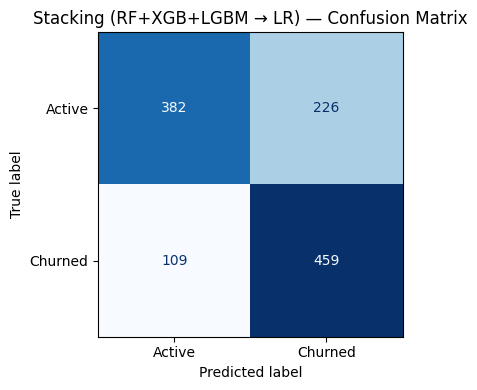


📌 Stacking Business Insight:
   Stacking is the most powerful ensemble but the least interpretable.
   In FMCG production use, you'd run Stacking for the monthly
   strategic churn report (high accuracy needed) and use a single
   DT or RF for the daily field rep dashboard (interpretability needed).
   Right tool for the right use case.



In [18]:
#Stacking
#ALGORITHM:
#   Level 0 (Base learners): multiple diverse models trained on training data
# each produces out-of-fold predictions
#   Level 1 (Meta learner) : trained on the base learner predictions
# learns WHEN to trust each base model
print("🏗️  Training Stacking Ensemble...")
print("    Base: RF + XGBoost + LightGBM")
print("    Meta: Logistic Regression\n")  

base_learners = [
    ("rf",    RandomForestClassifier(n_estimators=200, max_depth=10,
random_state=42, n_jobs=-1)),
    ("xgb", XGBClassifier(n_estimators=200, max_depth=4,learning_rate=0.05, subsample=0.8,use_label_encoder=False, eval_metric="auc",random_state=42, n_jobs=-1, verbosity=0)),
    ("lgbm",  LGBMClassifier(n_estimators=200, num_leaves=31,learning_rate=0.05, subsample=0.8,random_state=42, n_jobs=-1, verbose=-1))
]

meta_learner = LogisticRegression(
    C=1.0, max_iter=1000, random_state=42
)

stacking_model = StackingClassifier(
    estimators       = base_learners,
    final_estimator  = meta_learner,
    cv               = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    passthrough      = True,   # pass original features to meta-learner too
    n_jobs           = -1
)

stacking_model = evaluate(
    "Stacking (RF+XGB+LGBM → LR)",
    stacking_model,
    X_train, X_test, y_train, y_test
)

print("""
📌 Stacking Business Insight:
   Stacking is the most powerful ensemble but the least interpretable.
   In FMCG production use, you'd run Stacking for the monthly
   strategic churn report (high accuracy needed) and use a single
   DT or RF for the daily field rep dashboard (interpretability needed).
   Right tool for the right use case.
""")


In [19]:
#Cascading
#ALGORITHM:
#   A sequential pipeline of increasingly complex models
#   Stage 1 (fast, simple): catches easy cases with high confidence
#   Stage 2 (slower, complex): handles remaining uncertain cases
#
# THRESHOLD LOGIC:
#   If model confidence >= HIGH_THRESHOLD → classify immediately (confident)
#   If model confidence <= LOW_THRESHOLD  → classify immediately (confident)
#   Otherwise                             → pass to next stage
print("🔗 Building Cascading Classifier...")
print("   Stage 1: Naive Bayes (fast, handles confident cases)")
print("   Stage 2: LightGBM   (handles uncertain cases)\n")

HIGH_THRESHOLD = 0.80
LOW_THRESHOLD  = 0.20

# Stage 1 — Naive Bayes
stage1 = GaussianNB()
stage1.fit(X_train_scaled, y_train)
proba_stage1 = stage1.predict_proba(X_test_scaled)[:, 1]

# Identify confident vs uncertain predictions
confident_mask   = (proba_stage1 >= HIGH_THRESHOLD) | (proba_stage1 <= LOW_THRESHOLD)
uncertain_mask   = ~confident_mask

n_confident  = confident_mask.sum()
n_uncertain  = uncertain_mask.sum()
print(f"   Stage 1 classified {n_confident} / {len(y_test)} "
      f"({n_confident/len(y_test)*100:.1f}%) confidently")
print(f"   Stage 2 needed for {n_uncertain} "
      f"({n_uncertain/len(y_test)*100:.1f}%) uncertain cases")

# Stage 2 — LightGBM on uncertain cases only
stage2 = LGBMClassifier(
    n_estimators=200, num_leaves=31,
    learning_rate=0.05, random_state=42,
    verbose=-1, n_jobs=-1
)

# For uncertain test cases, use corresponding unscaled features
X_uncertain_train = X_train[np.where(
    (stage1.predict_proba(X_train_scaled)[:, 1] >= HIGH_THRESHOLD) |
    (stage1.predict_proba(X_train_scaled)[:, 1] <= LOW_THRESHOLD),
    False, True
)]
y_uncertain_train = y_train[np.where(
    (stage1.predict_proba(X_train_scaled)[:, 1] >= HIGH_THRESHOLD) |
    (stage1.predict_proba(X_train_scaled)[:, 1] <= LOW_THRESHOLD),
    False, True
)]

if len(X_uncertain_train) > 10:
    stage2.fit(X_uncertain_train, y_uncertain_train)

# Combine predictions
final_preds = np.where(proba_stage1 >= HIGH_THRESHOLD, 1,
             np.where(proba_stage1 <= LOW_THRESHOLD,  0, -1))

if uncertain_mask.sum() > 0 and len(X_uncertain_train) > 10:
    uncertain_preds = stage2.predict(X_test[uncertain_mask])
    final_preds[uncertain_mask] = uncertain_preds

# Evaluate cascade
acc  = accuracy_score(y_test, final_preds)
f1   = f1_score(y_test, final_preds)
prec = precision_score(y_test, final_preds)
rec  = recall_score(y_test, final_preds)

print(f"\n{'='*55}")
print(f"  Cascading (NB → LightGBM)")
print(f"{'='*55}")
print(classification_report(y_test, final_preds,
      target_names=["Active", "Churned"]))

results.append({
    "Model"    : "Cascading (NB→LightGBM)",
    "Accuracy" : round(acc,  4),
    "Precision": round(prec, 4),
    "Recall"   : round(rec,  4),
    "F1"       : round(f1,   4),
    "ROC-AUC"  : None   # cascading doesn't produce unified probabilities
})

print("""
📌 Cascading Business Insight:
   Cascading is a latency optimization pattern, not just an accuracy one.
   In production FMCG churn scoring running on 50,000+ distributors
   nationally, running LightGBM on every distributor every day is expensive.
   Cascading lets NB handle the obvious cases (80%+ of distributors)
   and reserves the heavy model for edge cases only.
   This is how large-scale recommendation and risk systems are built.
""")

🔗 Building Cascading Classifier...
   Stage 1: Naive Bayes (fast, handles confident cases)
   Stage 2: LightGBM   (handles uncertain cases)

   Stage 1 classified 1057 / 1176 (89.9%) confidently
   Stage 2 needed for 119 (10.1%) uncertain cases

  Cascading (NB → LightGBM)
              precision    recall  f1-score   support

      Active       0.77      0.62      0.68       608
     Churned       0.66      0.80      0.72       568

    accuracy                           0.70      1176
   macro avg       0.71      0.71      0.70      1176
weighted avg       0.72      0.70      0.70      1176


📌 Cascading Business Insight:
   Cascading is a latency optimization pattern, not just an accuracy one.
   In production FMCG churn scoring running on 50,000+ distributors
   nationally, running LightGBM on every distributor every day is expensive.
   Cascading lets NB handle the obvious cases (80%+ of distributors)
   and reserves the heavy model for edge cases only.
   This is how large-scale 

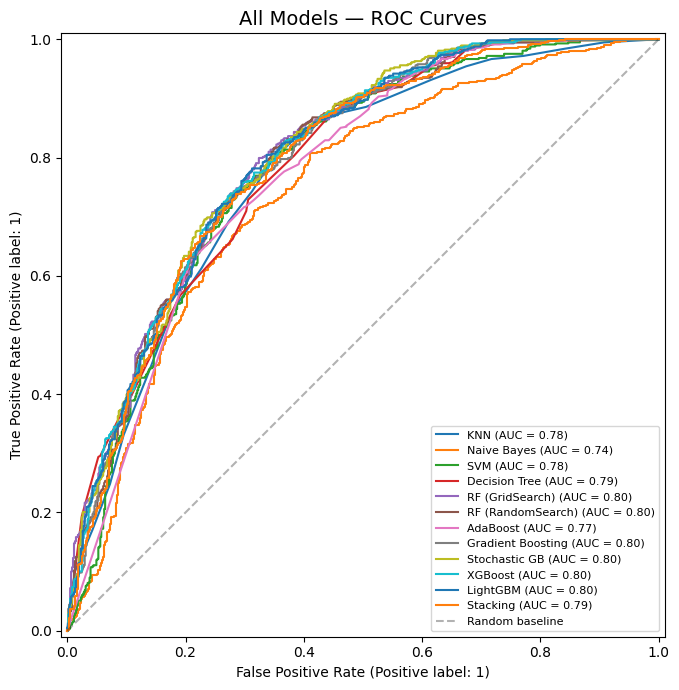

In [20]:
# ── ROC curves — all models ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

roc_models = {
    "KNN"                : (knn_model,      X_test_scaled),
    "Naive Bayes"        : (nb_model,       X_test_scaled),
    "SVM"                : (svm_model,      X_test_scaled),
    "Decision Tree"      : (dt_model,       X_test),
    "RF (GridSearch)"    : (rf_grid_model,  X_test),
    "RF (RandomSearch)"  : (rf_random_model,X_test),
    "AdaBoost"           : (ada_model,      X_test),
    "Gradient Boosting"  : (gb_model,       X_test),
    "Stochastic GB"      : (sgb_model,      X_test),
    "XGBoost"            : (xgb_model,      X_test),
    "LightGBM"           : (lgbm_model,     X_test),
    "Stacking"           : (stacking_model, X_test),
}

for name, (model, X_te) in roc_models.items():
    RocCurveDisplay.from_estimator(model, X_te, y_test, ax=ax, name=name)

ax.plot([0,1],[0,1], "k--", alpha=0.3, label="Random baseline")
ax.set_title("All Models — ROC Curves", fontsize=14)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("outputs/all_models_roc.png")
plt.show()


  FINAL MODEL COMPARISON — FMCG Distributor Churn Prediction
                             Model  Accuracy  Precision  Recall     F1  ROC-AUC
     Stochastic GB (subsample=0.8)    0.7202     0.6765  0.8063 0.7357   0.8040
      Random Forest (GridSearchCV)    0.7296     0.6796  0.8327 0.7484   0.8031
               XGBoost (round 211)    0.7262     0.6772  0.8275 0.7448   0.8023
                  Bagging (50 DTs)    0.7279     0.6808  0.8222 0.7448   0.8009
                          LightGBM    0.7262     0.6804  0.8169 0.7424   0.8008
Random Forest (RandomizedSearchCV)    0.7228     0.6709  0.8363 0.7445   0.7978
                 Gradient Boosintg    0.7100     0.6667  0.7993 0.7270   0.7978
       Stacking (RF+XGB+LGBM → LR)    0.7151     0.6701  0.8081 0.7326   0.7917
                      Decison Tree    0.7066     0.6618  0.8028 0.7255   0.7884
                     SVM (RBF,C=1)    0.7134     0.6667  0.8134 0.7328   0.7827
                               KNN    0.7219     0.6817  0

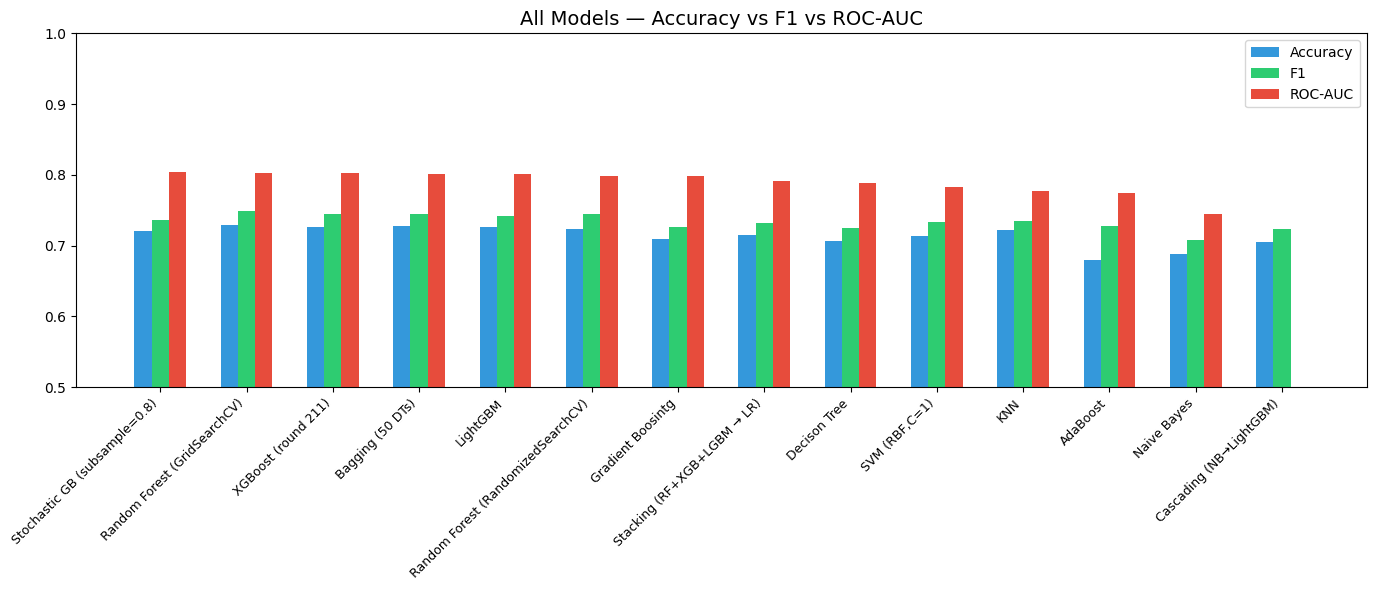


🏆 Best Model: Stochastic GB (subsample=0.8)
   Accuracy  : 0.7202
   Precision : 0.6765
   Recall    : 0.8063
   F1        : 0.7357
   ROC-AUC   : 0.804

📌 Final Business Recommendation:
   Production system recommendation:
   → Daily dashboard  : Naive Bayes or Decision Tree (fast + explainable)
   → Weekly report    : Random Forest or LightGBM (balanced accuracy)
   → Monthly strategy : Stacking ensemble (highest accuracy)
   → Field sales tool : Decision Tree rules (no ML knowledge needed)
   → At-risk alerts   : SHAP waterfall per distributor (actionable reasons)



In [21]:
# ── Final comparison table ────────────────────────────────────────────────────
df_results = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)

print("\n" + "="*75)
print("  FINAL MODEL COMPARISON — FMCG Distributor Churn Prediction")
print("="*75)
print(df_results.to_string(index=False))

# Save to CSV
df_results.to_csv("outputs/model_comparison.csv", index=False)
print("\n✅ Saved: outputs/model_comparison.csv")

# Bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x     = np.arange(len(df_results))
width = 0.2

ax.bar(x - width,  df_results["Accuracy"],  width, label="Accuracy",  color="#3498db")
ax.bar(x,          df_results["F1"],         width, label="F1",        color="#2ecc71")
ax.bar(x + width,  df_results["ROC-AUC"].fillna(0), width,
       label="ROC-AUC", color="#e74c3c")

ax.set_xticks(x)
ax.set_xticklabels(df_results["Model"], rotation=45, ha="right", fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.set_title("All Models — Accuracy vs F1 vs ROC-AUC", fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig("outputs/final_model_comparison.png")
plt.show()

# Best model summary
best = df_results.iloc[0]
print(f"""
🏆 Best Model: {best['Model']}
   Accuracy  : {best['Accuracy']}
   Precision : {best['Precision']}
   Recall    : {best['Recall']}
   F1        : {best['F1']}
   ROC-AUC   : {best['ROC-AUC']}

📌 Final Business Recommendation:
   Production system recommendation:
   → Daily dashboard  : Naive Bayes or Decision Tree (fast + explainable)
   → Weekly report    : Random Forest or LightGBM (balanced accuracy)
   → Monthly strategy : Stacking ensemble (highest accuracy)
   → Field sales tool : Decision Tree rules (no ML knowledge needed)
   → At-risk alerts   : SHAP waterfall per distributor (actionable reasons)
""")